<a href="https://colab.research.google.com/github/2007856reyli/act-y-pia/blob/main/AF%205.-%20Simulaci%C3%B3n%20de%20un%20sistema%20a%20partir%20de%20formalismo%20Euler-Lagrange.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad Autónoma de Nuevo León

## Facultad de Ingeniería Mecánica y Eléctrica (FIME)

### Simulación de un Robot Péndulo de 1 GDL mediante Euler-Lagrange

**Alumno:** Reyli Isaac Morales Zarazua

**Matrícula:** 2007856

**Carrera:** IMC


# Simulación de un Robot Péndulo de 1 GDL mediante Euler-Lagrange

En esta práctica se simula el comportamiento dinámico de un robot péndulo de un grado de libertad utilizando el modelo obtenido mediante el formalismo de Euler-Lagrange. La simulación se realiza en Python empleando el método numérico `solve_ivp` de la biblioteca SciPy.

## Importación de bibliotecas

Se importan las bibliotecas necesarias para realizar operaciones matemáticas, resolver ecuaciones diferenciales y graficar los resultados de la simulación.

In [19]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

## Definición de los parámetros del sistema

Se definen los parámetros físicos del robot péndulo proporcionados en la práctica.

In [20]:
Ir = 0.16
m = 5
g = 9.81
lc = 0.01
b = 0.14
fc = 0.45

## Definición del torque aplicado

Se define el torque ejercido por el motor sobre la articulación del robot. En este caso se utiliza una señal senoidal de amplitud 1.5 Nm.

In [21]:
def tau(t):
    return 1.5*np.sin(t)

## Modelo dinámico del robot

Se implementa la ecuación diferencial obtenida mediante el formalismo de Euler-Lagrange, considerando la gravedad, la fricción viscosa y la fricción de Coulomb.

In [22]:
def f(t,x):

    q = x[0]
    qp = x[1]

    friccion_coulomb = fc*np.tanh(100000*qp)

    qpp = (1/Ir)*(tau(t)-m*g*lc*np.sin(q)-b*qp-friccion_coulomb)

    return [qp,qpp]

## Configuración de la simulación

Se establece el intervalo de simulación de 10 segundos y las condiciones iniciales del sistema.

In [23]:
ti = 0
tf = 10
h = 0.0025

ts = np.arange(ti,tf,h)

q0 = 0
qp0 = 0

x0 = [q0,qp0]

## Resolución del sistema dinámico

Se resuelve la ecuación diferencial utilizando el método `solve_ivp`.

In [24]:
sol = solve_ivp(f,[ti,tf],x0,t_eval=ts)

t = sol.t
posicion = sol.y[0]
velocidad = sol.y[1]

## Conversión de unidades

La posición y la velocidad angular obtenidas en radianes se convierten a grados para facilitar su interpretación.

In [25]:
posicion_grados = np.rad2deg(posicion)
velocidad_grados = np.rad2deg(velocidad)

## Gráficas de la simulación

Se muestran las gráficas de la posición y la velocidad angular del robot péndulo durante los 10 segundos de simulación.

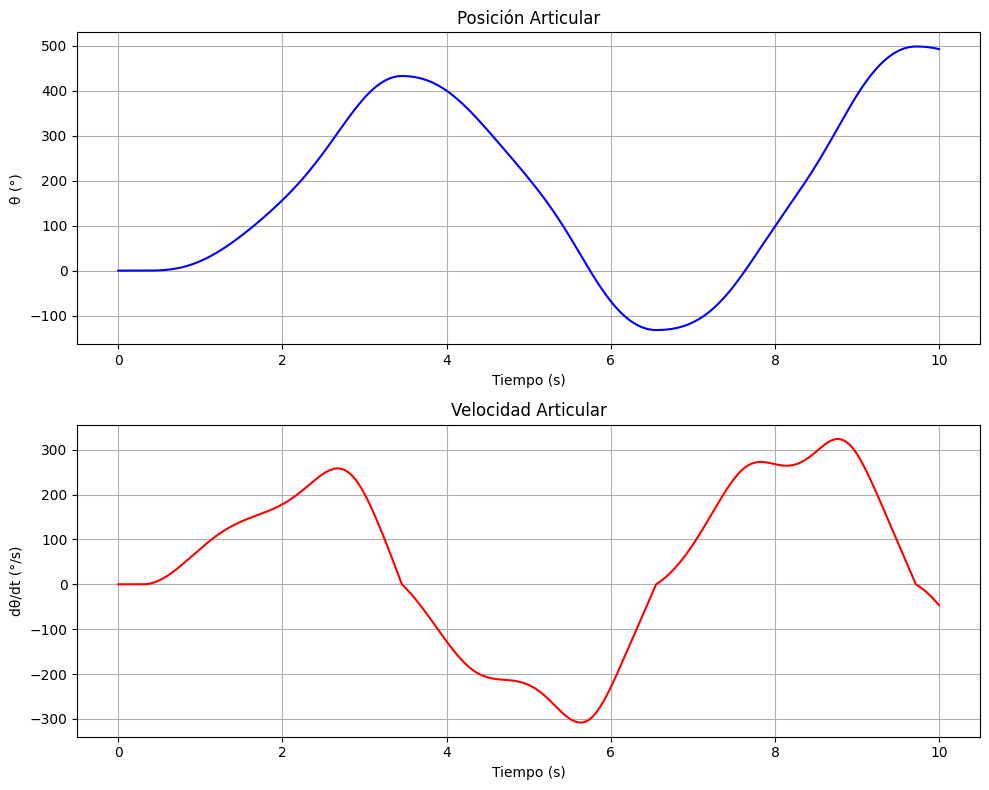

In [26]:
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(10,8))

ax1.plot(t,posicion_grados,'b')
ax1.set_title("Posición Articular")
ax1.set_xlabel("Tiempo (s)")
ax1.set_ylabel("θ (°)")
ax1.grid()

ax2.plot(t,velocidad_grados,'r')
ax2.set_title("Velocidad Articular")
ax2.set_xlabel("Tiempo (s)")
ax2.set_ylabel("dθ/dt (°/s)")
ax2.grid()

plt.tight_layout()
plt.show()

## Resultados de la simulación

Se muestran los valores finales de la posición y la velocidad angular obtenidos al concluir la simulación.

In [27]:
print("Posición final:",np.rad2deg(posicion[-1]),"grados")
print("Velocidad final:",np.rad2deg(velocidad[-1]),"grados/s")

Posición final: 492.9656096547061 grados
Velocidad final: -46.34833654722507 grados/s
